In [1]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls "/content/drive/MyDrive/preprocessed_dataset.zip"

/content/drive/MyDrive/preprocessed_dataset.zip


In [4]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [5]:
#unzip dataset into colab's temporary storage
sample_path = "/content/drive/MyDrive/preprocessed_dataset.zip"
with zipfile.ZipFile(sample_path, 'r') as zip_ref:
    zip_ref.extractall('/content/sample_data')

In [6]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [7]:
# Dataset class with data augmentation
class MaizeLeafDataset(Dataset):
    def __init__(self, root_dir, transform=None, max_boxes=10):
        self.root_dir = root_dir
        self.transform = transform
        self.max_boxes = max_boxes
        self.images_path = os.path.join(self.root_dir, 'images')
        self.labels_path = os.path.join(self.root_dir, 'labels')
        self.images = sorted([f for f in os.listdir(self.images_path) if f.endswith('.jpg') or f.endswith('.png')])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.images_path, img_name)
        label_name = os.path.splitext(img_name)[0] + '.txt'
        label_path = os.path.join(self.labels_path, label_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls = float(parts[0])
                    x_c = float(parts[1])
                    y_c = float(parts[2])
                    w = float(parts[3])
                    h = float(parts[4])
                    labels.append([cls, x_c, y_c, w, h])
        padded_labels = torch.zeros((self.max_boxes, 5))
        if len(labels) > 0:
            labels_tensor = torch.tensor(labels, dtype=torch.float32)
            n = min(len(labels), self.max_boxes)
            padded_labels[:n] = labels_tensor[:n]
        return image, padded_labels


In [8]:
# Data augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.Resize((416, 416)),
    transforms.ToTensor()
])
valid_transform = transforms.Compose([
    transforms.Resize((416, 416)),
    transforms.ToTensor()
])

In [9]:
# Dataset paths (adjust as necessary)
train_path = '/content/sample_data/train'
valid_path = '/content/sample_data/valid'
test_path = '/content/sample_data/test'
max_boxes = 10
batch_size = 8

train_dataset = MaizeLeafDataset(train_path, transform=train_transform, max_boxes=max_boxes)
valid_dataset = MaizeLeafDataset(valid_path, transform=valid_transform, max_boxes=max_boxes)
test_dataset = MaizeLeafDataset(test_path, transform=valid_transform, max_boxes=max_boxes)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [10]:
# Triple Attention
class TripleAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1 = nn.Conv2d(in_channels, in_channels // 8, 1, bias=False)
        self.relu = nn.ReLU()
        self.fc2 = nn.Conv2d(in_channels // 8, in_channels, 1, bias=False)

    def forward(self, x):
        avg_out = self.fc2(self.relu(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu(self.fc1(self.max_pool(x))))
        scale = torch.sigmoid(avg_out + max_out)
        return x * scale

# YOLOv9 model with triple attention
class YOLOv9(nn.Module):
    def __init__(self, num_classes=4, max_boxes=10):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            TripleAttention(64),
            nn.MaxPool2d(2, 2),  # 208x208
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            TripleAttention(128),
            nn.MaxPool2d(2, 2),  # 104x104
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            TripleAttention(256),
            nn.MaxPool2d(2, 2),  # 52x52
        )
        self.num_classes = num_classes
        self.max_boxes = max_boxes
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, max_boxes * (5 + num_classes))

)




    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        x = x.view(-1, self.max_boxes, 5 + self.num_classes)
        return x


In [11]:
# Loss function
def yolo_loss(preds, targets):
    batch_size = preds.size(0)
    max_boxes = preds.size(1)
    num_classes = preds.size(2) - 5

    pred_obj = preds[..., 0]
    pred_bbox = preds[..., 1:5]
    pred_cls = preds[..., 5:]

    target_cls = targets[..., 0].long()
    target_bbox = targets[..., 1:]
    obj_mask = (target_cls != 0).float()

    bce = nn.BCEWithLogitsLoss()
    obj_loss = bce(pred_obj, obj_mask)

    smooth_l1 = nn.SmoothL1Loss(reduction='none')
    bbox_loss_raw = smooth_l1(pred_bbox, target_bbox)
    bbox_loss = (bbox_loss_raw.sum(dim=2) * obj_mask).sum() / (obj_mask.sum() + 1e-6)

    ce = nn.CrossEntropyLoss(reduction='none')
    cls_loss_raw = ce(pred_cls.view(-1, num_classes), target_cls.view(-1))
    cls_loss = (cls_loss_raw.view(batch_size, max_boxes) * obj_mask).sum() / (obj_mask.sum() + 1e-6)

    total_loss = obj_loss + bbox_loss + cls_loss
    return total_loss, obj_loss.item(), bbox_loss.item(), cls_loss.item()

# Initialize model and optimizer
model = YOLOv9(num_classes=4, max_boxes=max_boxes).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
# Training loop
num_epochs = 20
train_losses, val_losses = [], []
print("Starting training...")
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss, obj_l, bbox_l, cls_l = yolo_loss(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss, _, _, _ = yolo_loss(outputs, labels)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(valid_loader)
    val_losses.append(avg_val_loss)
    # Print YOLO loss components
    print(f"Epoch [{epoch + 1}/{num_epochs}] - Loss: {avg_loss:.4f} - "
          f"Obj Loss: {obj_l:.4f}, BBox Loss: {bbox_l:.4f}, Cls Loss: {cls_l:.4f} - "
          f"Val Loss: {avg_val_loss:.4f}")
print("Training completed.")
#model save
torch.save(model.state_dict(), "maize_leaf_disease_model.pth")
print("Model saved successfully!")

Starting training...
Epoch [1/20] - Loss: 0.5833 - Obj Loss: 0.3950, BBox Loss: 0.1587, Cls Loss: 0.9915 - Val Loss: 0.4884
Epoch [2/20] - Loss: 0.3747 - Obj Loss: 0.0281, BBox Loss: 0.0050, Cls Loss: 0.0790 - Val Loss: 0.2902
Epoch [3/20] - Loss: 0.2995 - Obj Loss: 0.0173, BBox Loss: 0.0007, Cls Loss: 0.0002 - Val Loss: 0.2838
Epoch [4/20] - Loss: 0.3333 - Obj Loss: 0.1813, BBox Loss: 0.0903, Cls Loss: 0.0179 - Val Loss: 0.3217
Epoch [5/20] - Loss: 0.2708 - Obj Loss: 0.0919, BBox Loss: 0.0457, Cls Loss: 0.0022 - Val Loss: 0.2732
Epoch [6/20] - Loss: 0.2488 - Obj Loss: 0.0979, BBox Loss: 0.0372, Cls Loss: 0.3017 - Val Loss: 0.2649
Epoch [7/20] - Loss: 0.2514 - Obj Loss: 0.0442, BBox Loss: 0.0000, Cls Loss: 0.0000 - Val Loss: 0.3101
Epoch [8/20] - Loss: 0.2280 - Obj Loss: 0.0567, BBox Loss: 0.0674, Cls Loss: 0.0003 - Val Loss: 0.3431
Epoch [9/20] - Loss: 0.2457 - Obj Loss: 0.1624, BBox Loss: 0.0583, Cls Loss: 0.1496 - Val Loss: 0.3126
Epoch [10/20] - Loss: 0.2494 - Obj Loss: 0.0232, BBo

In [15]:
#Loading the saved model
model = YOLOv9(num_classes=4, max_boxes=max_boxes).to(device)
model.load_state_dict(torch.load("/content/maize_leaf_disease_model (1).pth", map_location=torch.device('cpu')))
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


Accuracy : 0.9463
Precision: 0.9455
Recall   : 0.9463
F1 Score : 0.9456


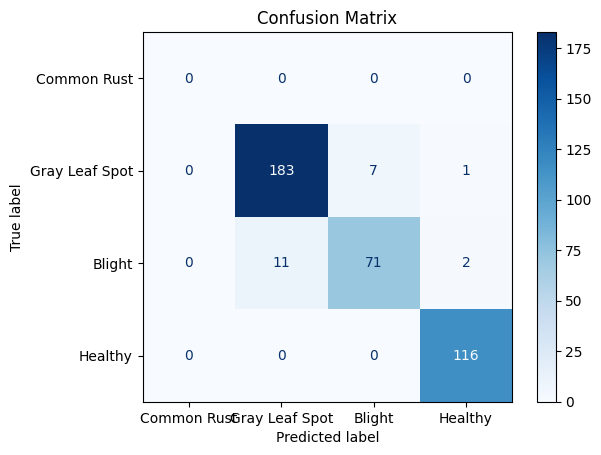

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import torch

# Class names
class_names = ["Common Rust", "Gray Leaf Spot", "Blight", "Healthy"]

ground_truths = []
predictions = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        # Predicted classes
        preds = torch.argmax(outputs[..., 5:], dim=-1)

        # Ground truth classes
        targets = labels[..., 0].long()

        # Loop through batch and boxes
        for i in range(preds.shape[0]):        # batch size
            for j in range(preds.shape[1]):    # max_boxes

                # Ignore padded boxes (important)
                if targets[i][j] != 0:
                    ground_truths.append(targets[i][j].item())
                    predictions.append(preds[i][j].item())

#Convert to list (just to be safe)
ground_truths = list(ground_truths)
predictions = list(predictions)

# Metrics
accuracy = accuracy_score(ground_truths, predictions)
precision = precision_score(ground_truths, predictions, average='weighted', zero_division=0)
recall = recall_score(ground_truths, predictions, average='weighted', zero_division=0)
f1 = f1_score(ground_truths, predictions, average='weighted', zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(ground_truths, predictions,labels=[0,1,2,3])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

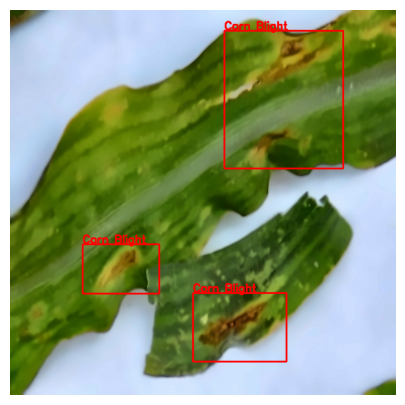

In [36]:
import cv2

# Define class_labels dictionary based on the class_names variable
class_labels = {
    0: "Corn Blight",
    1: "Common Rust",
    2: "Gray Leaf Spot",
    3: "Healthy"
}

def draw_boxes_with_labels(image_path, label_path):
    image = cv2.imread(image_path)
    # Check if image was loaded successfully
    if image is None:
        print(f"Error: Unable to load image from {image_path}")
        return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    with open(label_path, 'r') as f:
        for line in f.readlines():
            cls_id, x_c, y_c, bw, bh = line.strip().split()
            cls_id = int(cls_id)
            x_c, y_c, bw, bh = map(float, (x_c, y_c, bw, bh))
            x1 = int((x_c - bw/2) * w)
            y1 = int((y_c - bh/2) * h)
            x2 = int((x_c + bw/2) * w)
            y2 = int((y_c + bh/2) * h)
            cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
            label = class_labels.get(cls_id, "Unknown")
            cv2.putText(image, label, (x1, y1 -2), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    plt.figure(figsize=(10, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.show()
# Usage example — replace paths accordingly
image_path = '/content/sample_data/test/images/Corn_Blight-1-_jpg.rf.de59db5f8a42d4931ac66de4ecc4716c.jpg'
label_path = '/content/sample_data/test/labels/Corn_Blight-1-_jpg.rf.de59db5f8a42d4931ac66de4ecc4716c.txt'
draw_boxes_with_labels(image_path, label_path)